In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
# Read the student performance data from the CSV file in the same folder
df = pd.read_csv("students.csv")

# Look at the first 5 rows to confirm the data loaded correctly
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [3]:
# Show how many rows and columns are in the dataset
print("Shape (rows, columns):", df.shape)

# Show the data type of each column (int, float, object/string, etc.)
print("\nData types:")
print(df.dtypes)

Shape (rows, columns): (15, 9)

Data types:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [4]:
# Get summary statistics (count, mean, std, min, max, quartiles)
# for all numeric columns such as the subject scores
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [5]:
# Count how many students passed (1) and how many failed (0)
df["passed"].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [6]:
# List of subject columns we want to analyse
subject_cols = ["math", "science", "english", "history", "pe"]

# Calculate the average score for each subject among students who passed
pass_avg = df[df["passed"] == 1][subject_cols].mean()

# Calculate the average score for each subject among students who failed
fail_avg = df[df["passed"] == 0][subject_cols].mean()

print("Average scores for students who PASSED:")
print(pass_avg)

print("\nAverage scores for students who FAILED:")
print(fail_avg)

Average scores for students who PASSED:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average scores for students who FAILED:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


In [7]:
# Create a helper column 'subject_avg' as the mean of the 5 subjects for each student
df["subject_avg"] = df[subject_cols].mean(axis=1)

# Find the index (row number) of the student with the highest subject average
max_idx = df["subject_avg"].idxmax()

# Look up that student's name and average score
top_student = df.loc[max_idx, "name"]
top_average = df.loc[max_idx, "subject_avg"]

print(f"Top student by subject average: {top_student} with average {top_average:.2f}")

Top student by subject average: Diana with average 94.00


In [8]:
# Reuse the same list of subject columns defined earlier
subject_cols = ["math", "science", "english", "history", "pe"]

# Add a new column 'avg_score' that stores the average of the 5 subjects for each student
# axis=1 tells pandas to average across columns for each row
df["avg_score"] = df[subject_cols].mean(axis=1)

# Check that the new column looks reasonable for the first few students
df[["name", "avg_score"]].head()

,name,avg_score
0,Alice,86.2
1,Bob,51.0
2,Charlie,76.2
3,Diana,94.0
4,Eve,46.0


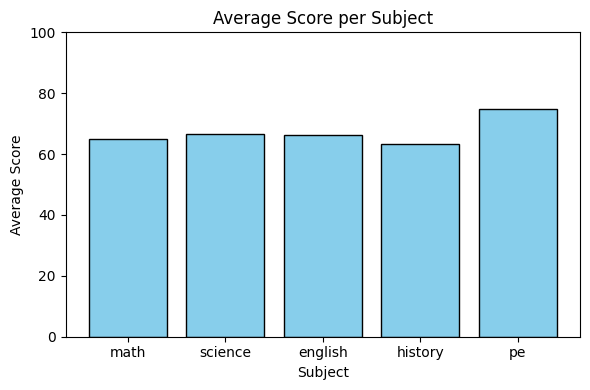

In [9]:
# Plot 1: Average score per subject (bar chart)

# Compute the mean score for each subject over all students
subject_means = df[subject_cols].mean()

# Start a new figure with a specific size (width x height in inches)
plt.figure(figsize=(6, 4))

# Draw bars: subject names on the x-axis, average scores on the y-axis
plt.bar(subject_means.index, subject_means.values,
        color="skyblue",       # fill color of the bars
        edgecolor="black")     # outline color of the bars

# Add a descriptive title and axis labels
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")

# Limit the y-axis between 0 and 100 to match exam score range
plt.ylim(0, 100)

# Tighten the layout so labels and title fit nicely
plt.tight_layout()

# Save the figure as a PNG file in the current folder
plt.savefig("plot1_bar.png")

# Show the bar chart inside the notebook
plt.show()

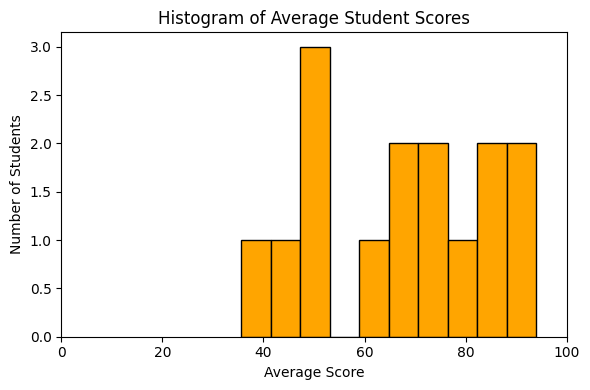

In [10]:
# Plot 2: Distribution of average scores (histogram)

plt.figure(figsize=(6, 4))

# Draw a histogram of the avg_score column
plt.hist(df["avg_score"],
         bins=10,          # number of bins / bars in the histogram
         color="orange",
         edgecolor="black")

plt.title("Histogram of Average Student Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

# Keep x-axis in the 0–100 exam range
plt.xlim(0, 100)

plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()

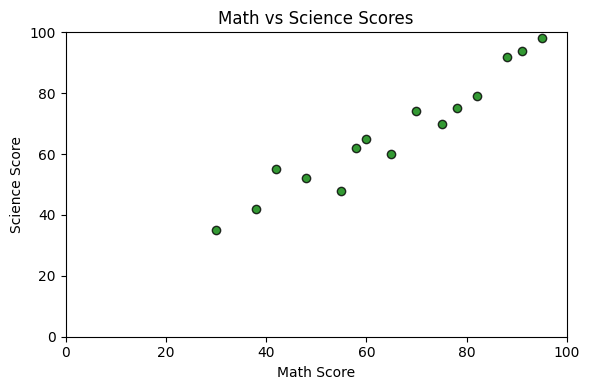

In [11]:
# Plot 3: Relationship between Math and Science scores (scatter plot)

plt.figure(figsize=(6, 4))

# Each point is one student, x = math score, y = science score
plt.scatter(df["math"], df["science"],
            color="green",
            alpha=0.8,      # slight transparency so overlapping points are visible
            edgecolors="black")

plt.title("Math vs Science Scores")
plt.xlabel("Math Score")
plt.ylabel("Science Score")

plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_7524\1603720406.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([avg_failed, avg_passed],


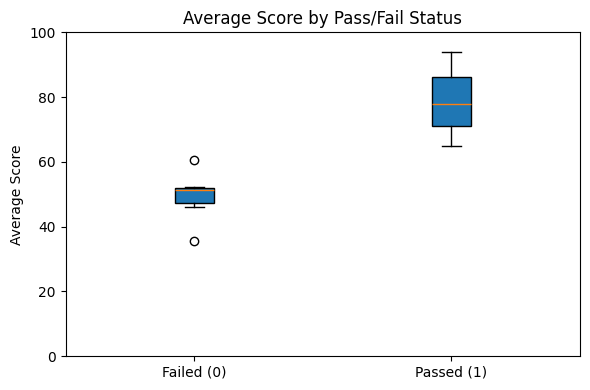

In [12]:
# Plot 4: Box plot of average scores grouped by pass/fail

plt.figure(figsize=(6, 4))

# Prepare data for each group: passed = 1, failed = 0
avg_passed = df[df["passed"] == 1]["avg_score"]
avg_failed = df[df["passed"] == 0]["avg_score"]

# Draw two box plots side by side
plt.boxplot([avg_failed, avg_passed],
            labels=["Failed (0)", "Passed (1)"],
            patch_artist=True)   # allow filling the boxes with color

plt.title("Average Score by Pass/Fail Status")
plt.ylabel("Average Score")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("plot4_box.png")
plt.show()

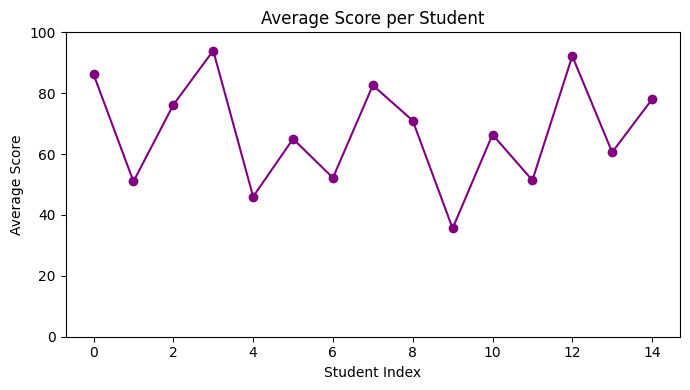

In [13]:
# Plot 5: Average score by student index (line chart)

plt.figure(figsize=(7, 4))

# Use the DataFrame index (0..N-1) as the x-axis
plt.plot(df.index, df["avg_score"],
         marker="o",        # show a marker at each student
         linestyle="-",
         color="purple")

plt.title("Average Score per Student")
plt.xlabel("Student Index")
plt.ylabel("Average Score")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_7524\102399994.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subject_means_df,


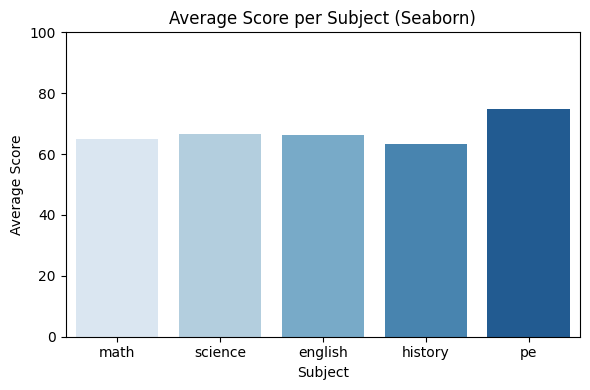

In [14]:
# Plot 6: Seaborn bar plot of average score per subject

# Use the same subject_means from before, or recompute for safety
subject_means = df[["math", "science", "english", "history", "pe"]].mean()

# Convert the means to a small DataFrame so seaborn can use column names easily
subject_means_df = subject_means.reset_index()
subject_means_df.columns = ["subject", "mean_score"]

plt.figure(figsize=(6, 4))

# seaborn barplot: x = subject name, y = mean score
sns.barplot(data=subject_means_df,
            x="subject",
            y="mean_score",
            palette="Blues")

plt.title("Average Score per Subject (Seaborn)")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

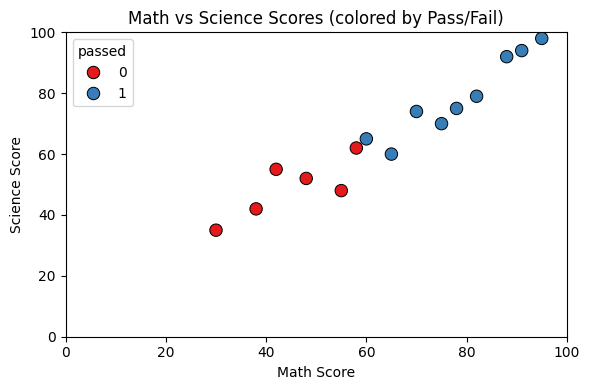

In [15]:
# Plot 7: Seaborn scatter plot of Math vs Science colored by pass/fail

plt.figure(figsize=(6, 4))

# seaborn scatterplot:
# x = math, y = science, hue = passed (0 or 1) to color points by pass/fail
sns.scatterplot(data=df,
                x="math",
                y="science",
                hue="passed",          # different color for passed / failed
                palette="Set1",
                s=80,                   # marker size
                edgecolor="black")

plt.title("Math vs Science Scores (colored by Pass/Fail)")
plt.xlabel("Math Score")
plt.ylabel("Science Score")
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [16]:
# Select the 5 subject scores as features (inputs to the model)
feature_cols = ["math", "science", "english", "history", "pe"]
X = df[feature_cols]

# Target variable: whether the student passed (1) or failed (0)
y = df["passed"]

In [17]:
# Split the data into training and test sets
# test_size=0.3 keeps 30% of rows for testing; random_state fixes the shuffle for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape[0], "rows")
print("Test set size:", X_test.shape[0], "rows")

Training set size: 10 rows
Test set size: 5 rows


In [18]:
# Create a StandardScaler to normalize features to mean 0 and std 1
scaler = StandardScaler()

# Fit the scaler only on the training data, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Create a logistic regression model (default settings are enough here)
log_reg = LogisticRegression()

# Fit the model on the scaled training data
log_reg.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
# Predict pass/fail for the test set
y_pred = log_reg.predict(X_test_scaled)

# Calculate accuracy as the proportion of correct predictions
accuracy = (y_pred == y_test).mean()
print(f"Test set accuracy: {accuracy:.2f}")

Test set accuracy: 0.80


In [21]:
# Each coefficient corresponds to one subject feature in feature_cols
coefficients = log_reg.coef_[0]

# Pair each subject with its coefficient
for feature, coef in zip(feature_cols, coefficients):
    print(f"{feature}: {coef:.3f}")

math: 0.574
science: 0.475
english: 0.713
history: 0.470
pe: 0.609


In [22]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefficients
}).sort_values(by="coefficient", ascending=False)

coef_df

,feature,coefficient
2,english,0.712621
4,pe,0.608635
0,math,0.574275
1,science,0.475013
3,history,0.470002
